# Generative Models: Autoencoders, VAEs, and PixelCNN

**Deep Learning — University of Vermont**

---

## Learning Objectives

By the end of this notebook you will be able to:

1. **Build a traditional autoencoder** by creating an encoder to compress input images into a latent vector and a decoder to reconstruct the original image.
2. **Implement a PixelCNN architecture** using masked convolutions.
3. **Construct a variational autoencoder (VAE)** that maps inputs to a probability distribution by outputting a mean and a standard deviation instead of a fixed point.
4. **Apply the reparameterization trick** to enable backpropagation through a random sampling process by shifting the noise to an external epsilon variable.
5. **Define a custom ELBO loss function** that optimizes the trade-off between reconstruction accuracy and the KL divergence of the latent space.
6. **Generate new images from scratch** by sampling random vectors from the learned normal distribution and passing them through the trained decoder.


## Setup and Imports

We use **PyTorch** and **torchvision** throughout. Our dataset is **MNIST** — 60,000
handwritten digits, each a 28×28 grayscale image. All three models in this notebook
train on MNIST so you can directly compare their outputs.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Pixel values in [0, 1] — no extra normalisation needed;
# Sigmoid outputs and BCE loss both expect this range.
transform = transforms.ToTensor()

from torch.utils.data import DataLoader, random_split

full_train = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

# 80/20 train/val split
n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train
train_data, val_data = random_split(full_train, [n_train, n_val],
                                    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data,   batch_size=128, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_data,  batch_size=128, shuffle=False, num_workers=0)

print(f'Train   : {len(train_data):,}')
print(f'Val     : {len(val_data):,}')
print(f'Test    : {len(test_data):,}')


Using device: cuda
Train   : 48,000
Val     : 12,000
Test    : 10,000


---
## 1. Autoencoder

### What is an Autoencoder?

An autoencoder is a neural network trained to **copy its input to its output** — but
with a twist: the data must first pass through a **narrow bottleneck** called the
**latent space** (or **latent vector** $z$).

Because the bottleneck is much smaller than the input, the network is forced to learn
a **compressed representation** that keeps only the most important features.

The network has two halves:

| Part | Job | Analogy |
|---|---|---|
| **Encoder** $f$ | Compress the image $x$ into a small vector $z = f(x)$ | Writing a summary |
| **Decoder** $g$ | Reconstruct the image from $z$: $\hat{x} = g(z)$ | Expanding the summary back into an essay |

![Autoencoder architecture](https://raw.githubusercontent.com/Lightning-AI/tutorials/main/course_UvA-DL/08-deep-autoencoders/autoencoder_visualization.svg)

*Autoencoder: encoder (left) compresses input to latent vector $z$; decoder (right) reconstructs the output (see References).*

### Reconstruction Loss

The model is trained to minimise the difference between the original image $x$ and the
reconstruction $\hat{x}$. Since pixel values are in $[0, 1]$, we use **Binary Cross-Entropy**:

$$\mathcal{L}_{\text{AE}} = -\frac{1}{N}\sum_{i=1}^{N}\Big[x_i \log \hat{x}_i + (1-x_i)\log(1-\hat{x}_i)\Big]$$

This loss is small when each predicted pixel $\hat{x}_i$ is close to the true pixel $x_i$.
Notice: there are **no labels** — the input image is both the input *and* the target.
This makes autoencoders a form of **self-supervised learning**.


In [2]:
# ── Autoencoder Architecture ──────────────────────────────────────────────
# Autoencoder architecture (see References)

LATENT_DIM = 32   # Size of the bottleneck vector z


class Encoder(nn.Module):
    """
    Compresses a (1, 28, 28) MNIST image into a latent vector of size LATENT_DIM.

    Spatial trace:
        Input  : 1  x 28 x 28
        Conv1  : 32 x 14 x 14   (stride=2 halves the spatial size)
        Conv2  : 64 x  7 x  7   (stride=2 halves again)
        Flatten: 3136
        Linear : LATENT_DIM
    """
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            # Strided convolution: learns to downsample (better than pooling)
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # -> 32x14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> 64x7x7
            nn.ReLU(),
            nn.Flatten(),                                            # -> 3136
            nn.Linear(64 * 7 * 7, latent_dim),                      # -> latent_dim
        )

    def forward(self, x):
        return self.net(x)   # (B, latent_dim)


class Decoder(nn.Module):
    """
    Reconstructs a (1, 28, 28) image from a latent vector.

    Spatial trace:
        Input         : LATENT_DIM
        Linear        : 3136  => reshape to 64 x 7 x 7
        ConvTranspose1: 32 x 14 x 14   (stride=2 doubles the spatial size)
        ConvTranspose2:  1 x 28 x 28   (stride=2 doubles again)
        Sigmoid       : clips output to [0, 1]
    """
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)  # Expand z to spatial volume
        self.net = nn.Sequential(
            # Transposed convolution: learned upsampling (reverse of strided conv)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # -> 32x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1,  kernel_size=4, stride=2, padding=1),  # -> 1x28x28
            nn.Sigmoid(),   # Pixel values must be in [0, 1] to match BCE targets
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 64, 7, 7)  # Reshape flat vector to feature map
        return self.net(h)                  # (B, 1, 28, 28)


class Autoencoder(nn.Module):
    """Connects Encoder and Decoder into a single model."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z    = self.encoder(x)   # Compress to latent
        xhat = self.decoder(z)   # Reconstruct from latent
        return xhat


ae = Autoencoder().to(device)
total_params = sum(p.numel() for p in ae.parameters())
print(f'Autoencoder parameters: {total_params:,}')
print(ae)


Autoencoder parameters: 256,001
Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
      (5): Linear(in_features=3136, out_features=32, bias=True)
    )
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=3136, bias=True)
    (net): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): Sigmoid()
    )
  )
)


### Training the Autoencoder

The training loop follows three steps each batch:

1. **Forward pass** — run the image through encoder then decoder to get a reconstruction.
2. **Loss** — compute BCE between the reconstruction and the original image.
3. **Backward pass** — compute gradients and update weights with Adam.

The target is the input image itself — no labels needed.


In [3]:
# ── Autoencoder Training ──────────────────────────────────────────────────

AE_EPOCHS = 10
ae_optimizer = optim.Adam(ae.parameters(), lr=1e-3)
ae_train_losses, ae_val_losses = [], []

print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12}")
print("-" * 36)
for epoch in range(1, AE_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────
    ae.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs  = imgs.to(device)
        recon = ae(imgs)
        loss  = F.binary_cross_entropy(recon, imgs, reduction='sum') / imgs.size(0)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        running_loss += loss.item()
    train_avg = running_loss / len(train_loader)

    # ── Validate ──────────────────────────────────────────────────────
    ae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs  = imgs.to(device)
            recon = ae(imgs)
            val_loss += F.binary_cross_entropy(recon, imgs, reduction='sum').item() / imgs.size(0)
    val_avg = val_loss / len(val_loader)

    ae_train_losses.append(train_avg)
    ae_val_losses.append(val_avg)
    print(f"{epoch:2d}/{AE_EPOCHS:<6} {train_avg:>12.4f} {val_avg:>12.4f}")


Epoch      Train Loss     Val Loss
------------------------------------
 1/10         130.8428      72.6679
 2/10          67.9556      64.9424
 3/10          63.7039      62.5141
 4/10          61.8969      61.2969
 5/10          60.8174      60.4304
 6/10          60.0916      59.9321
 7/10          59.5281      59.3440
 8/10          59.0883      59.0060
 9/10          58.7478      58.7453
10/10          58.4355      58.4446


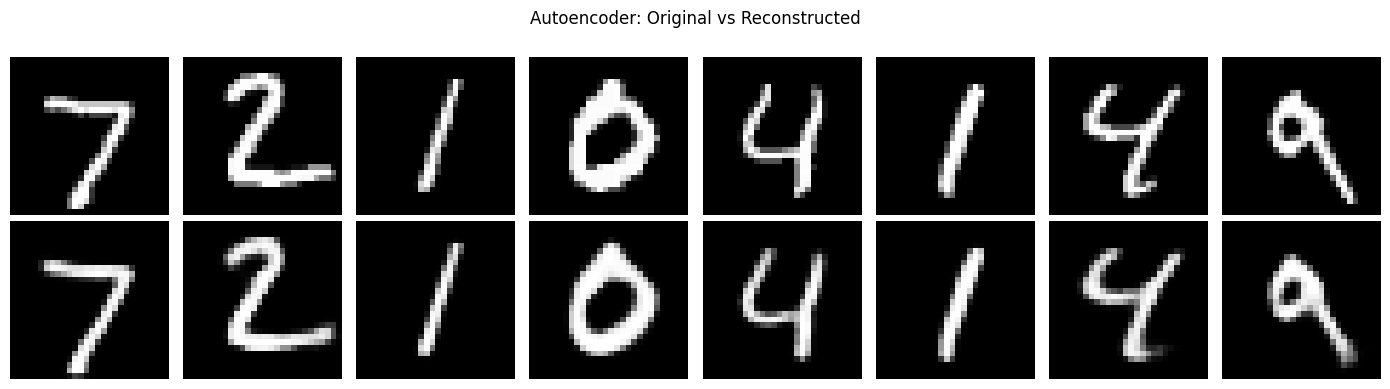

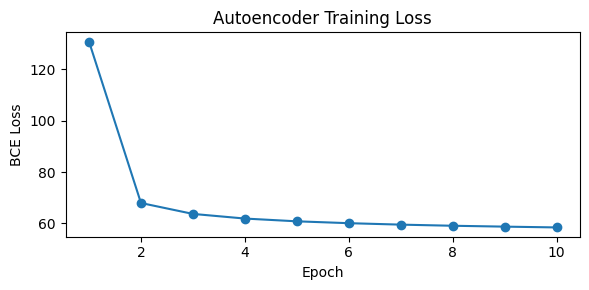

In [4]:
# ── Visualise Reconstructions ─────────────────────────────────────────────

ae.eval()
with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    imgs    = imgs[:8].to(device)
    recons  = ae(imgs).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
plt.suptitle('Autoencoder: Original vs Reconstructed')
plt.tight_layout()
plt.show()

# Training curve
plt.figure(figsize=(6, 3))
plt.plot(range(1, AE_EPOCHS + 1), ae_train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Autoencoder Training Loss')
plt.tight_layout()
plt.show()

---
## 2. PixelCNN

### What is PixelCNN?

The Autoencoder and VAE both compress an image into a latent vector and decode it all at once.
PixelCNN works completely differently: it generates an image **one pixel at a time**,
moving left-to-right, top-to-bottom — just like reading a book.

At each position the model asks one question:

> *"Given every pixel I have already placed, what value should go here?"*

This is called an **autoregressive model**. The probability of the whole image is
written as a chain of simpler conditional probabilities:

$$p(x) = p(x_1)\;\cdot\;p(x_2 \mid x_1)\;\cdot\;p(x_3 \mid x_1, x_2)\;\cdots\;p(x_n \mid x_1,\ldots,x_{n-1})$$

**In plain English:** the probability of the full image equals the probability of the first
pixel times the probability of the second pixel given the first, and so on.

---
### Step 1 — Fix a Pixel Ordering

Before generating anything, PixelCNN defines a strict order for every pixel:
start at the top-left corner, scan row by row, finish at the bottom-right.

![Pixel generation order](https://raw.githubusercontent.com/singh-hrituraj/PixelCNN-Pytorch/master/images/Sequence.png)

*Each pixel is generated one at a time in raster-scan order (left-to-right, top-to-bottom).
When predicting the starred pixel, all shaded pixels are already known.*

---
### Step 2 — The Problem: Regular Convolutions Can Cheat

A standard convolution kernel looks at **all** neighbouring pixels — including pixels
that come *after* the current position. That would be cheating: the model would see
future pixels it has not generated yet.

---
### Step 3 — The Fix: Masked Convolutions

The solution is a **masked convolution**: multiply the kernel weights by a binary mask
that zeroes out every position the model is not allowed to see.

![Masked convolution](https://raw.githubusercontent.com/singh-hrituraj/PixelCNN-Pytorch/master/images/Masked_Conv.png)

*A masked convolution kernel: the white cells are active (past pixels allowed),
the black cells are zeroed out (future pixels blocked).*

The mask is applied to the weights before every forward pass, so the network
physically cannot receive any gradient signal from future positions.

---
### Step 4 — Two Mask Types (A and B)

There are two variants of the mask, used in different layers:

![Mask types A and B](https://raw.githubusercontent.com/singh-hrituraj/PixelCNN-Pytorch/master/images/Masking.png)

| Mask | Centre pixel | Used where | Why |
|---|---|---|---|
| **Type A** | Excluded (0) | First layer only | The model must not see $x_i$ when predicting $x_i$ |
| **Type B** | Included (1) | All later layers | Later layers can safely use the centre pixel's own intermediate representation |

---
### The Full Architecture

Putting it all together, the network has three stages:

| Stage | Layer | What it does |
|---|---|---|
| **Input** | MaskedConv2d Type A (7×7) | Reads the image; cannot see the current pixel |
| **Hidden** | MaskedConv2d Type B (7×7) × N | Builds deeper features; allowed to use the current pixel's partial result from the previous layer |
| **Output** | Conv2d 1×1 | Collapses the channel dimension to produce one logit per pixel |

The logit is passed through a **sigmoid** to get a probability, then we sample 0 or 1
from a Bernoulli distribution to decide the pixel value.

### Training vs Generation

| Phase | How it works |
|---|---|
| **Training** | Feed the full ground-truth image at once; predict all pixels in parallel; use BCE loss |
| **Generation** | Start from a blank canvas; predict and fill one pixel at a time; 784 forward passes for a 28×28 image |

Training is fast (all pixels at once). Generation is slow (one pixel at a time).
This is the main trade-off of autoregressive models.


In [5]:
# ── PixelCNN with Masked Convolutions ────────────────────────────────────
# PixelCNN implementation (see References)
#
# Architecture overview (refer to the tables in the markdown above):
#   Layer 0      : MaskedConv2d Type A  -- "Input" row in the architecture table
#   Layers 1..N-1: MaskedConv2d Type B  -- "Hidden" row
#   Output layer : Conv2d 1x1           -- "Output" row


class MaskedConv2d(nn.Conv2d):
    """
    Conv2d with an autoregressive mask (see Step 3 & 4 diagrams above).

    Type A: zeroes out the centre pixel and everything to its right/below.
            --> used for the FIRST layer (Step 4, left mask in the diagram).

    Type B: zeroes out only positions to the right/below; keeps the centre.
            --> used for ALL SUBSEQUENT layers (Step 4, right mask in the diagram).
    """
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ('A', 'B'), "mask_type must be 'A' or 'B'"

        # Create a zero mask the same shape as the kernel weights
        self.register_buffer('mask', torch.zeros_like(self.weight))
        _, _, H, W = self.weight.shape

        # White cells in the Step 3 diagram -- always allowed
        self.mask[:, :, :H // 2, :]       = 1   # All rows above the centre row
        self.mask[:, :, H // 2, :W // 2]  = 1   # Left half of the centre row

        # Centre pixel: included for Type B, excluded for Type A (Step 4)
        if mask_type == 'B':
            self.mask[:, :, H // 2, W // 2] = 1

    def forward(self, x):
        # Apply mask every pass so zeroed weights can never receive gradients
        self.weight.data *= self.mask
        return super().forward(x)


class PixelCNN(nn.Module):
    """
    Simple PixelCNN for binarised MNIST.
    Follows the three-stage architecture from the table in the markdown above.
    """
    def __init__(self, n_channels=64, n_layers=7):
        super().__init__()
        layers = []

        # ── STAGE 1: Input layer (architecture table row 1) ───────────────
        # Type A mask: the model cannot see the pixel it is predicting.
        # kernel_size=7 gives a large receptive field over the image.
        layers.append(MaskedConv2d('A', 1, n_channels, kernel_size=7, padding=3))
        layers.append(nn.ReLU())

        # ── STAGE 2: Hidden layers (architecture table row 2) ─────────────
        # Type B mask: can use the centre pixel's own representation from
        # the previous layer (safe because earlier layers already masked it).
        for _ in range(n_layers - 1):
            layers.append(MaskedConv2d('B', n_channels, n_channels,
                                       kernel_size=7, padding=3))
            layers.append(nn.ReLU())

        # ── STAGE 3: Output layer (architecture table row 3) ──────────────
        # 1x1 conv collapses n_channels -> 1 logit per pixel.
        # sigmoid(logit) = probability that this pixel is 1.
        layers.append(nn.Conv2d(n_channels, 1, kernel_size=1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)   # (B, 1, 28, 28) — one logit per pixel


pixel_cnn = PixelCNN().to(device)
total_params = sum(p.numel() for p in pixel_cnn.parameters())
print(f'PixelCNN parameters: {total_params:,}')
print(pixel_cnn)


PixelCNN parameters: 1,207,873
PixelCNN(
  (net): Sequential(
    (0): MaskedConv2d(1, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): ReLU()
    (2): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (3): ReLU()
    (4): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (5): ReLU()
    (6): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (7): ReLU()
    (8): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (9): ReLU()
    (10): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (11): ReLU()
    (12): MaskedConv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (13): ReLU()
    (14): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)


### Training PixelCNN

We binarise MNIST images (pixels above 0.5 become 1, the rest 0) and train the network
to predict each pixel given all pixels before it.

During training, the full ground-truth image is fed as input — this is called
**teacher forcing**. The network outputs a logit for every pixel position at once,
and the loss is binary cross-entropy averaged over all pixels.

At **generation** time (next cell), we cannot use teacher forcing — we must generate
pixel-by-pixel, writing each sampled value back into the canvas before moving to the next.


In [6]:
# ── PixelCNN Training ─────────────────────────────────────────────────────

PIXEL_EPOCHS = 10
pixel_optimizer = optim.Adam(pixel_cnn.parameters(), lr=1e-3)
pixel_train_losses, pixel_val_losses = [], []

print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12}")
print("-" * 36)
for epoch in range(1, PIXEL_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────
    pixel_cnn.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs        = imgs.to(device)
        binary_imgs = (imgs > 0.5).float()
        logits      = pixel_cnn(binary_imgs)
        loss        = F.binary_cross_entropy_with_logits(logits, binary_imgs)
        pixel_optimizer.zero_grad()
        loss.backward()
        pixel_optimizer.step()
        running_loss += loss.item()
    train_avg = running_loss / len(train_loader)

    # ── Validate ──────────────────────────────────────────────────────
    pixel_cnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs        = imgs.to(device)
            binary_imgs = (imgs > 0.5).float()
            logits      = pixel_cnn(binary_imgs)
            val_loss   += F.binary_cross_entropy_with_logits(logits, binary_imgs).item()
    val_avg = val_loss / len(val_loader)

    pixel_train_losses.append(train_avg)
    pixel_val_losses.append(val_avg)
    print(f"{epoch:2d}/{PIXEL_EPOCHS:<6} {train_avg:>12.4f} {val_avg:>12.4f}")


Epoch      Train Loss     Val Loss
------------------------------------
 1/10           0.1906       0.0965
 2/10           0.0917       0.0903
 3/10           0.0862       0.0845
 4/10           0.0839       0.0826
 5/10           0.0826       0.0834
 6/10           0.0817       0.0811
 7/10           0.0810       0.0805
 8/10           0.0803       0.0797
 9/10           0.0798       0.0795
10/10           0.0792       0.0802


Generating images pixel by pixel...
Done.


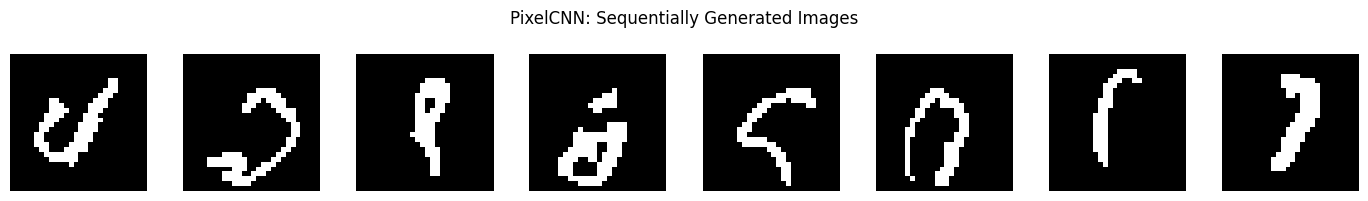

In [7]:
# ── PixelCNN Sequential Generation ───────────────────────────────────────
#
# Generation is slow: for each of the 28x28 = 784 pixel positions we must:
#   1. Run the full network on the canvas.
#   2. Read the logit at position (row, col).
#   3. Sample 0 or 1 from a Bernoulli distribution.
#   4. Write the sampled value into the canvas.
#   5. Move to the next position.
# The masks ensure each step only uses pixels already generated.

pixel_cnn.eval()
N = 8                                              # Number of images to generate
canvas = torch.zeros(N, 1, 28, 28).to(device)     # Start from a blank canvas

print('Generating images pixel by pixel...')
with torch.no_grad():
    for row in range(28):
        for col in range(28):
            logits = pixel_cnn(canvas)              # Full forward pass
            probs  = torch.sigmoid(logits[:, :, row, col])  # Prob for this pixel
            pixel  = torch.bernoulli(probs)         # Sample 0 or 1
            canvas[:, :, row, col] = pixel          # Write into canvas
print('Done.')

fig, axes = plt.subplots(1, N, figsize=(14, 2))
for i in range(N):
    axes[i].imshow(canvas[i].cpu().squeeze(), cmap='gray')
    axes[i].axis('off')
plt.suptitle('PixelCNN: Sequentially Generated Images')
plt.tight_layout()
plt.show()


---
## 3. Construct a Variational Autoencoder (VAE)

### The Problem with Regular Autoencoders

The autoencoder maps each image to a **single fixed point** $z$ in latent space.
This works for reconstruction, but has a hidden problem: the latent space can be
**irregular and full of gaps**. If you pick a random point and run it through the
decoder you will often get a blurry mess — that point was never seen during training.

### The Fix: Map to a Distribution Instead of a Point

A VAE maps each image to a **Gaussian distribution** rather than a single point.
The encoder no longer outputs one vector — it outputs **two vectors**:
$\mu$ (mean) and $\log\sigma^2$ (log-variance), which together define a bell curve
in latent space:

| Model | Encoder output |
|---|---|
| Autoencoder | One fixed vector $z$ |
| VAE | Mean $\mu$ + log-variance $\log\sigma^2$ → a Gaussian $\mathcal{N}(\mu, \sigma^2)$ |

![VAE architecture](https://lilianweng.github.io/posts/2018-08-12-vae/vae-gaussian.png)

*VAE: the encoder outputs $\mu$ and $\sigma$; the decoder reconstructs from a sample
$z \sim \mathcal{N}(\mu, \sigma^2)$ (see References).*

The KL divergence term in the loss (Section 5) forces all these distributions to
stay close to $\mathcal{N}(0, I)$, filling the gaps and making any random point
in latent space decode into something meaningful.

### The VAE Architecture

The encoder and decoder are almost identical to the Autoencoder from Section 1,
with one key change: the encoder head is **split into two linear layers** — one for
$\mu$ and one for $\log\sigma^2$ — instead of a single output layer.


In [8]:
# ── Variational Autoencoder: Architecture (LO 3) ─────────────────────────
# VAE implementation (see References)

VAE_LATENT_DIM = 32


class VAE(nn.Module):
    """
    Variational Autoencoder for 28x28 MNIST images.

    Key difference from the plain Autoencoder (Section 1):
      - Encoder outputs (mu, logvar) instead of a single z.    [LO 3]
      - z is sampled via the reparameterization trick.         [LO 4]
      - Loss = BCE reconstruction + KL divergence (ELBO).     [LO 5]
      - New images are generated by sampling z from N(0, I).  [LO 6]
    """
    def __init__(self, latent_dim=VAE_LATENT_DIM):
        super().__init__()

        # ── Encoder: image -> shared features -> two heads ────────────
        self.enc_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # -> 32x14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> 64x7x7
            nn.ReLU(),
            nn.Flatten(),                                            # -> 3136
        )
        # Two separate heads — this is what makes it a VAE (LO 3)
        self.fc_mu     = nn.Linear(64 * 7 * 7, latent_dim)  # Predicts mean mu
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)  # Predicts log-variance

        # ── Decoder: z -> image (same as Autoencoder Section 1) ───────
        self.fc_dec = nn.Linear(latent_dim, 64 * 7 * 7)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1,  kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        """Returns (mu, logvar) — the Gaussian parameters for each image."""
        h = self.enc_conv(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        """Reparameterization trick — explained in Section 4 below."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        """Expand z back to a (1, 28, 28) image."""
        h = self.fc_dec(z).view(-1, 64, 7, 7)
        return self.dec_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)   # Sample z (LO 4)
        return self.decode(z), mu, logvar


vae = VAE().to(device)
print(f'VAE parameters: {sum(p.numel() for p in vae.parameters()):,}')


VAE parameters: 356,385


---
## 4. The Reparameterization Trick

### The Problem: Sampling is Not Differentiable

To train the VAE with backpropagation, gradients must flow all the way from the
decoder loss back to the encoder weights. But the encoder produces $\mu$ and $\sigma$,
and we **sample** $z \sim \mathcal{N}(\mu, \sigma^2)$ from them.

Sampling is a **random operation** — it has no derivative. Gradients cannot pass
through a random draw, so the encoder would receive no training signal.

### The Fix: Move the Noise Outside

Instead of sampling $z$ directly, **factor out the randomness** into a separate
variable $\varepsilon$ that the network never has to differentiate through:

$$z = \mu + \sigma \cdot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

| Version | Differentiable? | Why |
|---|---|---|
| $z \sim \mathcal{N}(\mu, \sigma^2)$ — sample directly | **No** | The random draw has no gradient |
| $z = \mu + \sigma \cdot \varepsilon$, $\varepsilon \sim \mathcal{N}(0,I)$ | **Yes** | $\varepsilon$ is a constant input; gradients flow through $\mu$ and $\sigma$ |

![Reparameterization trick](https://lilianweng.github.io/posts/2018-08-12-vae/reparameterization-trick.png)

*Left: direct sampling — no gradient path to encoder. Right: reparameterized —
gradient flows cleanly through $\mu$ and $\sigma$ (see References).*

This is already implemented in `vae.reparameterize()` above. The cell below
demonstrates it in isolation so you can see exactly what it does.


In [9]:
# ── Reparameterization Trick: Demonstration (LO 4) ───────────────────────
# Shows that sampling z = mu + sigma * eps is equivalent to z ~ N(mu, sigma^2)
# but keeps the computation graph intact for backpropagation.

torch.manual_seed(42)

# Pretend the encoder output mu=2, logvar=log(0.25)=log(sigma^2) for one dimension
mu     = torch.tensor([[2.0]])
logvar = torch.tensor([[float(torch.log(torch.tensor(0.25)))]])  # sigma^2 = 0.25

# Sample z using the reparameterization trick
z = vae.reparameterize(mu, logvar)
print(f'mu     = {mu.item():.3f}')
print(f'sigma  = {torch.exp(0.5 * logvar).item():.3f}')
print(f'z      = {z.item():.3f}   (should be near mu=2, with spread ~ sigma=0.5)')

# Run many times to confirm the distribution is correct
samples = torch.stack([vae.reparameterize(mu, logvar) for _ in range(5000)]).squeeze()
print(f'\n5000 samples — mean: {samples.mean():.3f}  std: {samples.std():.3f}')
print(f'Expected        — mean: {mu.item():.3f}  std: {torch.exp(0.5*logvar).item():.3f}')


mu     = 2.000
sigma  = 0.500
z      = 2.168   (should be near mu=2, with spread ~ sigma=0.5)

5000 samples — mean: 2.004  std: 0.492
Expected        — mean: 2.000  std: 0.500


---
## 5. The ELBO Loss Function

### Two Goals, One Loss

The VAE must optimise two things at once:

| Goal | Loss term | Effect |
|---|---|---|
| Reconstruct the input accurately | **Reconstruction loss** (BCE) | Pushes decoder to reproduce the original image |
| Keep the latent space smooth | **KL divergence** | Pushes the encoder's distributions toward $\mathcal{N}(0, I)$ |

These two terms are combined into the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}_{\text{ELBO}} = \underbrace{\mathcal{L}_{\text{recon}}}_{\text{BCE}} + \underbrace{D_{\text{KL}}\!\left(q(z|x) \| \mathcal{N}(0,I)\right)}_{\text{KL regulariser}}$$

The KL divergence has a closed-form solution for Gaussians:

$$D_{\text{KL}} = -\frac{1}{2}\sum_{j=1}^{d}\Big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\Big)$$

We predict $\log\sigma^2$ (called `logvar`) for numerical stability;
then $\sigma = e^{\,0.5 \cdot \text{logvar}}$.

### Trade-off

If the KL weight is too high the latent space becomes too compressed
(poor reconstructions). If it is too low, the latent space has gaps
(poor generation). The ELBO balances both automatically during training.


In [10]:
# ── ELBO Loss + VAE Training (LO 5) ──────────────────────────────────────

def elbo_loss(recon_x, x, mu, logvar):
    """
    ELBO = Reconstruction loss + KL divergence.

    Both terms summed over all elements, then normalised by batch size.
    """
    # Term 1: how well did we rebuild the input? (BCE per pixel)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # Term 2: KL divergence — closed form for N(mu, sigma^2) vs N(0, I)
    # = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return (recon_loss + kl_div) / x.size(0)   # Average over batch


# ── Training loop ─────────────────────────────────────────────────────────
VAE_EPOCHS    = 10
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
vae_train_losses, vae_val_losses = [], []

print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12}")
print("-" * 36)
for epoch in range(1, VAE_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────
    vae.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        recon, mu, logvar = vae(imgs)
        loss = elbo_loss(recon, imgs, mu, logvar)
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
        running_loss += loss.item()
    train_avg = running_loss / len(train_loader)

    # ── Validate ──────────────────────────────────────────────────────
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            recon, mu, logvar = vae(imgs)
            val_loss += elbo_loss(recon, imgs, mu, logvar).item()
    val_avg = val_loss / len(val_loader)

    vae_train_losses.append(train_avg)
    vae_val_losses.append(val_avg)
    print(f"{epoch:2d}/{VAE_EPOCHS:<6} {train_avg:>12.4f} {val_avg:>12.4f}")


Epoch      Train Loss     Val Loss
------------------------------------
 1/10         157.9681     120.5475
 2/10         115.6140     112.2854
 3/10         110.8267     109.4201
 4/10         108.6545     108.0057
 5/10         107.3355     106.8368
 6/10         106.4740     106.0238
 7/10         105.8248     105.5983
 8/10         105.2991     105.2321
 9/10         104.9078     104.7404
10/10         104.5492     104.4605


---
## 6. Generate New Images from Scratch

### How Generation Works

Now that the VAE is trained, we can generate brand-new images that were never
in the training set. The KL loss (Section 5) ensures the latent space is smooth
and well-organised around $\mathcal{N}(0, I)$, so **any random point we sample
from that distribution will decode into a plausible image**:

| Step | Action |
|---|---|
| 1 | Sample a random latent vector $z \sim \mathcal{N}(0, I)$ — no real image needed |
| 2 | Pass $z$ through the decoder to get a generated image $\hat{x} = g(z)$ |

Compare this to reconstruction (which starts from a real image $x$):

| Mode | Input | What you get |
|---|---|---|
| Reconstruction | Real image $x$ | $\hat{x} \approx x$ |
| **Generation** | Random $z \sim \mathcal{N}(0,I)$ | A new image not in the training set |


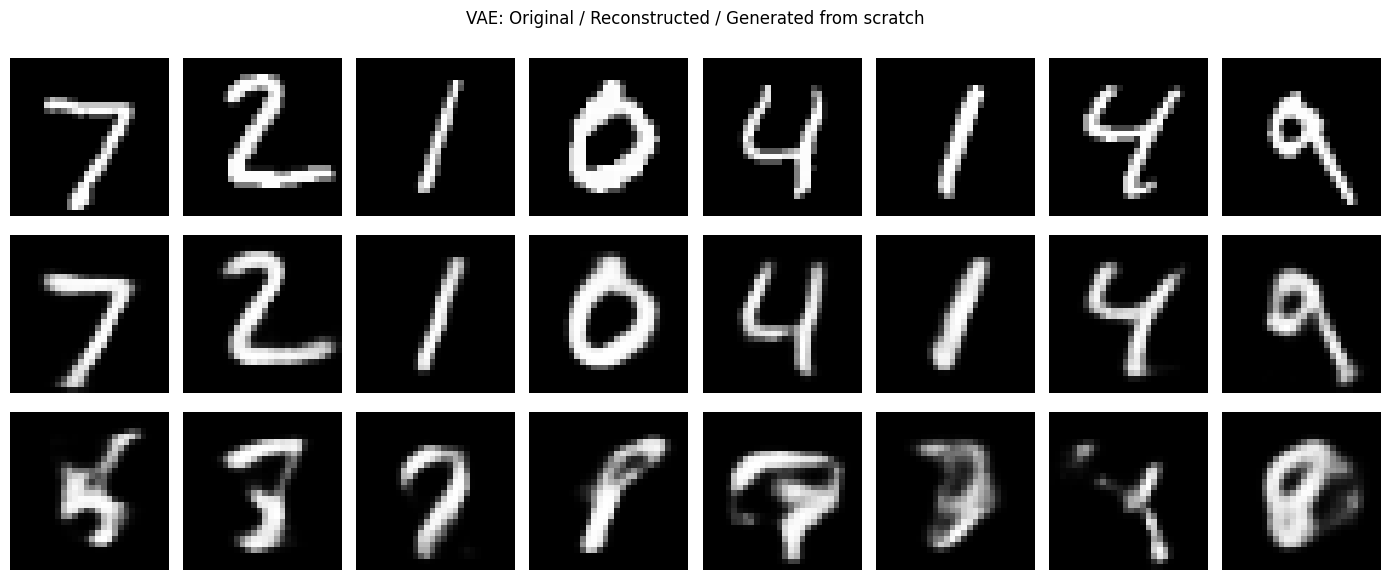

In [11]:
# ── Generate New Images from Scratch (LO 6) ──────────────────────────────

vae.eval()
with torch.no_grad():
    # Reconstructions — encode real images, decode back
    imgs, _ = next(iter(test_loader))
    imgs    = imgs[:8].to(device)
    recons, _, _ = vae(imgs)
    recons  = recons.cpu()

    # Generation — sample z from N(0, I) and decode (no real image needed)
    z_random  = torch.randn(8, VAE_LATENT_DIM).to(device)  # Step 1
    generated = vae.decode(z_random).cpu()                  # Step 2

fig, axes = plt.subplots(3, 8, figsize=(14, 6))
row_labels = ['Original', 'Reconstructed', 'Generated (from N(0,I))']
row_data   = [imgs.cpu(), recons, generated]

for row_idx, (label, row_imgs) in enumerate(zip(row_labels, row_data)):
    for col in range(8):
        axes[row_idx, col].imshow(row_imgs[col].squeeze(), cmap='gray')
        axes[row_idx, col].axis('off')
    axes[row_idx, 0].set_ylabel(label, fontsize=9)

plt.suptitle('VAE: Original / Reconstructed / Generated from scratch')
plt.tight_layout()
plt.show()


---
## Exercises

Each exercise builds directly on code from sections above. Fill in the `TODO` lines
only — the rest of the scaffolding is already written for you.


### Exercise 1: Visualise the 2D Latent Space

#### Context

In Section 1 the autoencoder was trained with `LATENT_DIM = 32`. The 32D latent
vectors are not directly visualisable. If we shrink the bottleneck to just **2 dimensions**,
we can scatter-plot every test image as a single point and colour it by digit class.

A well-trained 2D autoencoder should form **10 recognisable clusters** — one per digit.
Digits that look similar (e.g. 3 and 8, or 4 and 9) will be close together.

#### Your task

Fill in the two `TODO` lines:

| TODO | What to write |
|---|---|
| 1 | Create an `Autoencoder` with `latent_dim=2` and send it to `device` |
| 2 | Call the encoder on `imgs` to get the 2D latent vectors |

#### Expected output

A scatter plot with 10 coloured clusters, one per digit class.


Epoch 1/5 done
Epoch 2/5 done
Epoch 3/5 done
Epoch 4/5 done
Epoch 5/5 done


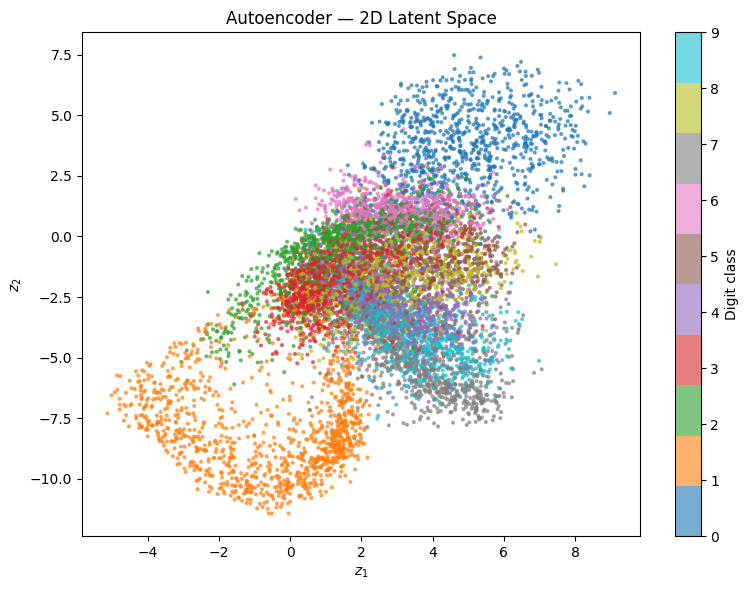

In [20]:
# ── Exercise 1: 2D Autoencoder Latent Space ──────────────────────────────

# TODO 1: create an Autoencoder with latent_dim=2 and send to device
ae_2d = Autoencoder(latent_dim=2).to(device)  # TODO: Autoencoder(latent_dim=2).to(device)

_ex1_ready = ae_2d is not None

if _ex1_ready:
    # Train for a few epochs (5 is enough to see structure)
    ae2d_opt = optim.Adam(ae_2d.parameters(), lr=1e-3)
    for epoch in range(1, 6):
        ae_2d.train()
        for imgs, _ in train_loader:
            imgs  = imgs.to(device)
            recon = ae_2d(imgs)
            loss  = F.binary_cross_entropy(recon, imgs, reduction='sum') / imgs.size(0)
            ae2d_opt.zero_grad()
            loss.backward()
            ae2d_opt.step()
        print(f'Epoch {epoch}/5 done')

    # Collect all 2D latent vectors from the test set
    ae_2d.eval()
    all_z, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            # TODO 2: encode imgs to get the 2D z vectors
            z =  ae_2d.encoder(imgs)  # TODO: ae_2d.encoder(imgs)
            if z is None: break
            all_z.append(z.cpu())
            all_labels.append(labels)

    if all_z:
        all_z      = torch.cat(all_z).numpy()
        all_labels = torch.cat(all_labels).numpy()
        plt.figure(figsize=(8, 6))
        sc = plt.scatter(all_z[:, 0], all_z[:, 1],
                         c=all_labels, cmap='tab10', s=4, alpha=0.6)
        plt.colorbar(sc, label='Digit class')
        plt.title('Autoencoder — 2D Latent Space')
        plt.xlabel('$z_1$'); plt.ylabel('$z_2$')
        plt.tight_layout(); plt.show()
    else:
        print('Complete TODO 2 to run the visualisation.')
else:
    print('Complete TODO 1 to run Exercise 1.')


### Exercise 2: Interpolate Between Two Digits in VAE Latent Space

#### Context

Because the VAE's latent space is smooth, you can **interpolate** between two latent
points and the decoder will produce meaningful images all the way along the path.

Interpolation formula: given latent codes $\mu_a$ and $\mu_b$ and a blend factor
$\alpha \in [0, 1]$:

$$z_{\text{interp}} = (1 - \alpha)\,\mu_a + \alpha\,\mu_b$$

At $\alpha = 0$ you get digit $a$; at $\alpha = 1$ you get digit $b$;
in between you get a smooth morphing sequence.

#### Your task

Fill in the two `TODO` lines:

| TODO | What to write |
|---|---|
| 1 | Encode `img_a` to get `mu_a` — call `vae.encode(img_a)` and take the first return value |
| 2 | Compute `z_interp = (1 - alpha) * mu_a + alpha * mu_b` |

#### Expected output

8 images that smoothly morph from digit 3 (left) to digit 8 (right).


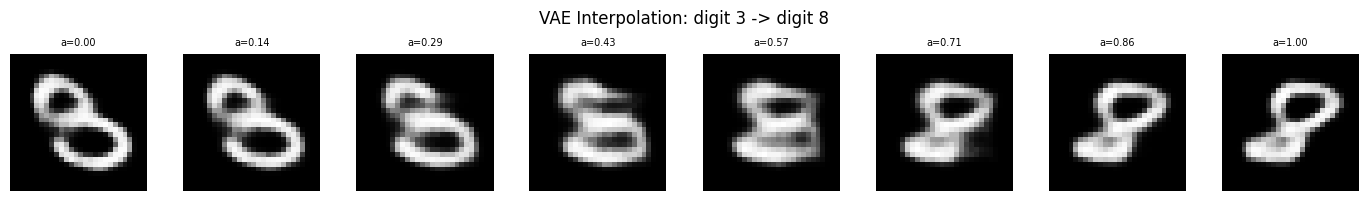

In [22]:
# ── Exercise 2: VAE Latent Space Interpolation ───────────────────────────

# Pick one image of digit 3 and one of digit 8 from the test set
imgs_by_class = {}
for imgs, labels in test_loader:
    for img, label in zip(imgs, labels):
        c = label.item()
        if c not in imgs_by_class:
            imgs_by_class[c] = img
    if 3 in imgs_by_class and 8 in imgs_by_class:
        break

img_a = imgs_by_class[3].unsqueeze(0).to(device)  # Digit 3: shape (1, 1, 28, 28)
img_b = imgs_by_class[8].unsqueeze(0).to(device)  # Digit 8

vae.eval()
with torch.no_grad():
    # TODO 1: encode img_a and img_b to get their mean latent codes
    # Hint: vae.encode(img) returns (mu, logvar) — we only need mu
    mu_a = vae.encode(img_a)[0]  # TODO: vae.encode(img_a)[0]
    mu_b = vae.encode(img_b)[0]  # TODO: vae.encode(img_b)[0]

    if mu_a is not None and mu_b is not None:
        alphas  = torch.linspace(0, 1, 8)
        interps = []
        for alpha in alphas:
            # TODO 2: compute the interpolated latent vector
            z_interp = (1 - alpha) * mu_a + alpha * mu_b  # TODO: (1 - alpha) * mu_a + alpha * mu_b
            if z_interp is None: break
            interps.append(vae.decode(z_interp).cpu())

        if interps:
            fig, axes = plt.subplots(1, 8, figsize=(14, 2))
            for i, (img, alpha) in enumerate(zip(interps, alphas)):
                axes[i].imshow(img.squeeze(), cmap='gray')
                axes[i].axis('off')
                axes[i].set_title(f'a={alpha:.2f}', fontsize=7)
            plt.suptitle('VAE Interpolation: digit 3 -> digit 8')
            plt.tight_layout(); plt.show()
        else:
            print('Complete TODO 2 to see the interpolation.')
    else:
        print('Complete TODO 1 to run Exercise 2.')

### Exercise 3: Inspect the Masked Convolution

#### Context

In Section 3 you built `MaskedConv2d`. The mask is the key mechanism that enforces
the autoregressive ordering — without it, the network could cheat by looking at
future pixels.

#### Your task

Create a Type A and a Type B `MaskedConv2d` with a **3×3** kernel (instead of 7×7),
then print their masks and verify the centre pixel rules.

Fill in the two `TODO` lines:

| TODO | What to write |
|---|---|
| 1 | `MaskedConv2d('A', 1, 1, kernel_size=3, padding=1)` |
| 2 | `MaskedConv2d('B', 1, 1, kernel_size=3, padding=1)` |

#### Expected output

```
Type A mask — centre [1,1] = 0:    Type B mask — centre [1,1] = 1:
[[1. 1. 1.]                         [[1. 1. 1.]
 [1. 0. 0.]                          [1. 1. 0.]
 [0. 0. 0.]]                         [0. 0. 0.]]
```


In [18]:
# ── Exercise 3: Inspect Masked Convolution Masks ─────────────────────────

# TODO 1: create a Type A MaskedConv2d  (1 in, 1 out, 3x3 kernel)
conv_a = MaskedConv2d('A', 1, 1, kernel_size=3, padding=1)  # TODO: MaskedConv2d('A', 1, 1, kernel_size=3, padding=1)

# TODO 2: create a Type B MaskedConv2d  (same dimensions)
conv_b = MaskedConv2d('B', 1, 1, kernel_size=3, padding=1)  # TODO: MaskedConv2d('B', 1, 1, kernel_size=3, padding=1)

if conv_a is not None and conv_b is not None:
    mask_a = conv_a.mask[0, 0].numpy()
    mask_b = conv_b.mask[0, 0].numpy()

    print('Type A mask (3x3):')
    print(mask_a)
    print(f'Centre pixel [1,1] = {mask_a[1, 1]:.0f}  (expected 0 — cannot see current pixel)\n')

    print('Type B mask (3x3):')
    print(mask_b)
    print(f'Centre pixel [1,1] = {mask_b[1, 1]:.0f}  (expected 1 — can use own representation)')
else:
    print('Complete the TODOs above to run Exercise 3.')


Type A mask (3x3):
[[1. 1. 1.]
 [1. 0. 0.]
 [0. 0. 0.]]
Centre pixel [1,1] = 0  (expected 0 — cannot see current pixel)

Type B mask (3x3):
[[1. 1. 1.]
 [1. 1. 0.]
 [0. 0. 0.]]
Centre pixel [1,1] = 1  (expected 1 — can use own representation)


---
## References

All code in this notebook is adapted from the following sources:

1. **PyTorch VAE Example** — Official implementation of the Variational Autoencoder
   https://github.com/pytorch/examples/blob/main/vae/main.py

2. **Kingma & Welling (2013)** — *Auto-Encoding Variational Bayes* (VAE paper)
   https://arxiv.org/abs/1312.6114

3. **van den Oord et al. (2016)** — *Pixel Recurrent Neural Networks* (PixelCNN)
   https://arxiv.org/abs/1601.06759

4. **Zhang et al.** — *Dive into Deep Learning*, PixelCNN chapter
   https://d2l.ai

5. **Wikipedia** — Autoencoder architecture diagram
   https://en.wikipedia.org/wiki/Autoencoder
